# Exercício 3 — Análise de pesquisas eleitorais

**Integrantes:** Andrey Salomão Almeida e Omar Habdalah Halada Saliba  
**Pergunta principal:** quão próximas as pesquisas eleitorais ficaram dos resultados reais e o que podemos aprender com os registros públicos de pesquisas no Brasil?

## 1. Introdução

O objetivo é limpar bases públicas e comparar pesquisas eleitorais com resultados reais. No final, mostramos uma pesquisa atual do Brasil.

## 2. Bases públicas utilizadas

1. [TSE — Pesquisas Eleitorais de 2014](https://dadosabertos.tse.jus.br/dataset/pesquisas-eleitorais-2014)
2. [TSE — Pesquisas Eleitorais de 2018](https://dadosabertos.tse.jus.br/dataset/pesquisas-eleitorais-2018)
3. [TSE — Pesquisas Eleitorais de 2022](https://dadosabertos.tse.jus.br/dataset/pesquisas-eleitorais-2022)
4. [TSE — Pesquisas Eleitorais de 2026](https://dadosabertos.tse.jus.br/dataset/pesquisas-eleitorais-2026)
5. [FiveThirtyEight — avaliação dos institutos](https://github.com/fivethirtyeight/data/tree/master/pollster-ratings)
6. [MIT Election Data and Science Lab — resultados eleitorais](https://electionlab.mit.edu/data)
7. [AtlasIntel/Bloomberg — pesquisa nacional de julho de 2026](https://cdn.atlasintel.org/498dd172-4381-4192-977c-c4af9787434f.pdf)

## 3. Importância da análise

Analisar pesquisas eleitorais ajuda a acompanhar mudanças na opinião dos eleitores e a verificar se as estimativas ficaram próximas dos resultados reais. A pesquisa mostra um momento da campanha, não uma certeza sobre o resultado.

## 4. Preparação do ambiente

Usaremos apenas `pandas`, `numpy`, `matplotlib` e `pathlib`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")

RAW = Path("data/raw")
PROCESSED = Path("data/processed")
FINAL = Path("data/final")
PROCESSED.mkdir(parents=True, exist_ok=True)
FINAL.mkdir(parents=True, exist_ok=True)

## 5. Carregamento dos dados históricos

Primeiro carregamos a base e conferimos seu tamanho, colunas e valores ausentes.

In [2]:
arquivo_538 = RAW / "fivethirtyeight/raw_polls.csv"
pesquisas_brutas = pd.read_csv(arquivo_538, low_memory=False)

print("Dimensão da base bruta:", pesquisas_brutas.shape)
pesquisas_brutas.head()

Dimensão da base bruta: (20466, 30)


,poll_id,question_id,race_id,cycle,location,type_simple,race,pollster,pollster_rating_id,aapor_roper,inactive,methodology,transparency_score,partisan,polldate,electiondate,time_to_election,samplesize,cand1_name,cand1_id,cand1_party,cand1_pct,cand1_actual,cand2_name,cand2_id,cand2_party,cand2_pct,cand2_actual,margin_poll,margin_actual
0,32945,39543,1,2014,NE,Sen-G,2014_Sen-G_NE,YouGov,391,False,False,Online Panel,8.0,NaN,2014-09-26,2014-11-04,39,721.0,Dave Domina,6263,DEM,31.0,31.485351,Ben Sasse,6269,REP,58.0,64.336886,-27.0,-32.851535
1,33777,40963,1,2014,NE,Sen-G,2014_Sen-G_NE,YouGov,391,False,False,Online Panel,8.0,NaN,2014-10-20,2014-11-04,15,681.0,Dave Domina,6263,DEM,30.0,31.485351,Ben Sasse,6269,REP,59.0,64.336886,-29.0,-32.851535
2,33068,126637,2,2014,MI,Sen-G,2014_Sen-G_MI,Public Policy Polling,263,False,False,IVR/Online Panel,5.0,NaN,2014-09-06,2014-11-04,59,687.0,Gary C. Peters,6053,DEM,43.0,54.614384,Terri Lynn Land,6052,REP,36.0,41.329073,7.0,13.285311
3,33061,39666,2,2014,MI,Sen-G,2014_Sen-G_MI,Suffolk University,323,True,False,Live Phone,8.0,NaN,2014-09-08,2014-11-04,57,500.0,Gary C. Peters,6053,DEM,45.6,54.614384,Terri Lynn Land,6052,REP,36.8,41.329073,8.8,13.285311
4,33037,39642,2,2014,MI,Sen-G,2014_Sen-G_MI,Denno Research,582,False,False,Live Phone,6.0,NaN,2014-09-12,2014-11-04,53,600.0,Gary C. Peters,6053,DEM,44.7,54.614384,Terri Lynn Land,6052,REP,37.7,41.329073,7.0,13.285311


In [3]:
pesquisas_brutas.info()
print("\nDuplicatas completas:", pesquisas_brutas.duplicated().sum())
print("\nValores ausentes nas colunas principais:")
display(
    pesquisas_brutas[["pollster", "methodology", "polldate", "samplesize",
                      "cand1_pct", "cand1_actual", "cand2_pct", "cand2_actual"]]
    .isna().sum().to_frame("ausentes")
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20466 entries, 0 to 20465
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   poll_id             20466 non-null  int64  
 1   question_id         20466 non-null  int64  
 2   race_id             20466 non-null  int64  
 3   cycle               20466 non-null  int64  
 4   location            20466 non-null  object 
 5   type_simple         20466 non-null  object 
 6   race                20466 non-null  object 
 7   pollster            20466 non-null  object 
 8   pollster_rating_id  20466 non-null  int64  
 9   aapor_roper         20466 non-null  bool   
 10  inactive            20466 non-null  bool   
 11  methodology         16915 non-null  object 
 12  transparency_score  20466 non-null  float64
 13  partisan            2556 non-null   object 
 14  polldate            20466 non-null  object 
 15  electiondate        20466 non-null  object 
 16  time

,ausentes
pollster,0
methodology,3551
polldate,0
samplesize,0
cand1_pct,0
cand1_actual,0
cand2_pct,0
cand2_actual,0


## 6. Limpeza dos dados históricos

Selecionamos pesquisas presidenciais de 2012, 2016 e 2020 dos quatro institutos disponíveis.

In [4]:
institutos_escolhidos = ["AtlasIntel", "Ipsos", "YouGov", "Marist College"]
anos_escolhidos = [2012, 2016, 2020]

filtro = (
    pesquisas_brutas["type_simple"].eq("Pres-G")
    & pesquisas_brutas["cycle"].isin(anos_escolhidos)
    & pesquisas_brutas["pollster"].isin(institutos_escolhidos)
)

pesquisas = pesquisas_brutas.loc[filtro].copy()
pesquisas["pollster"] = pesquisas["pollster"].replace({"Marist College": "Marist"})

pesquisas["polldate"] = pd.to_datetime(pesquisas["polldate"], errors="coerce")
pesquisas["electiondate"] = pd.to_datetime(pesquisas["electiondate"], errors="coerce")

colunas_numericas = ["samplesize", "cand1_pct", "cand1_actual",
                    "cand2_pct", "cand2_actual", "margin_poll", "margin_actual"]
for coluna in colunas_numericas:
    pesquisas[coluna] = pd.to_numeric(pesquisas[coluna], errors="coerce")

duplicatas_antes = pesquisas.duplicated().sum()
pesquisas = pesquisas.drop_duplicates().copy()

pesquisas["days_to_election"] = (
    pesquisas["electiondate"] - pesquisas["polldate"]
).dt.days
pesquisas = pesquisas[pesquisas["days_to_election"] >= 0].copy()

print("Duplicatas removidas:", duplicatas_antes)
print("Dimensão após o recorte e a limpeza:", pesquisas.shape)

Duplicatas removidas: 0
Dimensão após o recorte e a limpeza: (582, 31)


Cada pesquisa possui dois candidatos na mesma linha. A seguir, separamos um candidato por linha.

In [5]:
colunas_comuns = ["poll_id", "question_id", "race", "cycle", "location",
                  "pollster", "polldate", "electiondate",
                  "days_to_election", "samplesize", "methodology"]

candidato_1 = pesquisas[colunas_comuns + ["cand1_name", "cand1_party",
                                             "cand1_pct", "cand1_actual"]].copy()
candidato_1 = candidato_1.rename(columns={
    "cand1_name": "candidate", "cand1_party": "party",
    "cand1_pct": "poll_pct", "cand1_actual": "actual_pct"
})

candidato_2 = pesquisas[colunas_comuns + ["cand2_name", "cand2_party",
                                             "cand2_pct", "cand2_actual"]].copy()
candidato_2 = candidato_2.rename(columns={
    "cand2_name": "candidate", "cand2_party": "party",
    "cand2_pct": "poll_pct", "cand2_actual": "actual_pct"
})

pesquisas_candidatos = pd.concat([candidato_1, candidato_2], ignore_index=True)
pesquisas_candidatos.head()

,poll_id,question_id,race,cycle,location,pollster,polldate,electiondate,days_to_election,samplesize,methodology,candidate,party,poll_pct,actual_pct
0,27174,24357,2012_Pres-G_US,2012,US,Ipsos,2012-09-09,2012-11-06,58,873.0,NaN,Barack Obama,DEM,48.0,50.909185
1,19108,24428,2012_Pres-G_US,2012,US,Ipsos,2012-09-11,2012-11-06,56,990.0,Online Panel,Barack Obama,DEM,48.0,50.909185
2,29391,34907,2012_Pres-G_US,2012,US,YouGov,2012-09-16,2012-11-06,51,943.0,Online Panel,Barack Obama,DEM,49.0,50.909185
3,29517,35131,2012_Pres-G_US,2012,US,Ipsos,2012-09-19,2012-11-06,48,1616.0,Online Panel,Barack Obama,DEM,48.0,50.909185
4,29598,35689,2012_Pres-G_US,2012,US,YouGov,2012-09-23,2012-11-06,44,896.0,Online Panel,Barack Obama,DEM,48.0,50.909185


### Cálculo dos erros

Erro assinado = pesquisa − resultado. O erro absoluto mostra apenas a distância em pontos percentuais.

In [6]:
pesquisas_candidatos["signed_error"] = (
    pesquisas_candidatos["poll_pct"] - pesquisas_candidatos["actual_pct"]
)
pesquisas_candidatos["absolute_error"] = pesquisas_candidatos["signed_error"].abs()
pesquisas_candidatos["source_url"] = (
    "https://github.com/fivethirtyeight/data/tree/master/pollster-ratings"
)
pesquisas_candidatos["official_result_url"] = "https://electionlab.mit.edu/data"

pesquisas["margin_error"] = pesquisas["margin_poll"] - pesquisas["margin_actual"]
pesquisas["absolute_margin_error"] = pesquisas["margin_error"].abs()
pesquisas["winner_correct"] = (
    np.sign(pesquisas["margin_poll"]) == np.sign(pesquisas["margin_actual"])
)

print("Valores ausentes após a limpeza:")
display(
    pesquisas_candidatos[["poll_pct", "actual_pct", "samplesize", "methodology"]]
    .isna().sum().to_frame("ausentes")
)

Valores ausentes após a limpeza:


,ausentes
poll_pct,0
actual_pct,0
samplesize,0
methodology,2


In [7]:
pesquisas.to_csv(PROCESSED / "polls_us_clean.csv", index=False)
pesquisas_candidatos.to_csv(PROCESSED / "polls_us_candidates.csv", index=False)
print("Arquivos históricos tratados salvos em data/processed.")

Arquivos históricos tratados salvos em data/processed.


## 7. Registros brasileiros do TSE

Reunimos os arquivos de 2014, 2018, 2022 e 2026.

In [8]:
arquivos_tse = {
    2014: RAW / "tse_pesqele/2014/pesquisa_eleitoral_2014_BR.csv",
    2018: RAW / "tse_pesqele/2018/pesquisa_eleitoral_2018_BR.csv",
    2022: RAW / "tse_pesqele/2022/pesquisa_eleitoral_2022_BR.csv",
    2026: RAW / "tse_pesqele/2026/pesquisa_eleitoral_2026_BRASIL.csv",
}

partes_tse = []
colunas_tse = [
    "AA_ELEICAO", "NR_PROTOCOLO_REGISTRO", "DT_REGISTRO",
    "NM_EMPRESA", "DS_CARGO", "DT_INICIO_PESQUISA",
    "DT_FIM_PESQUISA", "QT_ENTREVISTADO", "VR_PESQUISA",
    "DS_METODOLOGIA_PESQUISA", "DS_PLANO_AMOSTRAL", "NM_CONTRATANTE"
]

for ano, caminho in arquivos_tse.items():
    parte = pd.read_csv(caminho, sep=";", encoding="latin1", low_memory=False)
    parte = parte.rename(columns={
        "DS_CARGOS": "DS_CARGO",
        "QT_ENTREVISTADOS": "QT_ENTREVISTADO"
    })
    for coluna in colunas_tse:
        if coluna not in parte.columns:
            parte[coluna] = np.nan
    parte = parte[colunas_tse].copy()
    parte["ano_arquivo"] = ano
    partes_tse.append(parte)

tse_bruto = pd.concat(partes_tse, ignore_index=True)
print("Dimensão dos registros reunidos:", tse_bruto.shape)
tse_bruto.head()

Dimensão dos registros reunidos: (4360, 13)


,AA_ELEICAO,NR_PROTOCOLO_REGISTRO,DT_REGISTRO,NM_EMPRESA,DS_CARGO,DT_INICIO_PESQUISA,DT_FIM_PESQUISA,QT_ENTREVISTADO,VR_PESQUISA,DS_METODOLOGIA_PESQUISA,DS_PLANO_AMOSTRAL,NM_CONTRATANTE,ano_arquivo
0,2014,BR000102014,2014-02-11 00:00:00,OPINIÃO PESQUISA ANÁLISE E CONSULTORIA LTDA,Presidente,2014-02-07 00:00:00,2014-02-13 00:00:00,500,"10000,00",Pesquisa quantitativa com aplicação de questio...,- Percentuais a serem utilizados para eventual...,NaN,2014
1,2014,BR000542014,2014-03-21 00:00:00,GK DE OLIVEIRA PRODUÇÕES ME,Presidente,2014-03-22 00:00:00,2014-03-25 00:00:00,2000,"15000,00","Pesquisa quantitativa, que consiste na realiza...","As cotas quanto a sexo, idade, escolaridade e ...",NaN,2014
2,2014,BR000532014,2014-03-21 00:00:00,IBOPE INTELIGÊNCIA PESQUISA E CONSULTORIA LTDA.,Presidente,2014-03-14 00:00:00,2014-03-17 00:00:00,2002,"214600,00","Pesquisa quantitativa, que consiste na realiza...",Representativa do eleitorado da área em estudo...,NaN,2014
3,2014,BR000632014,2014-03-31 00:00:00,"Gualberto, Orrico e Caliman Ltda",Presidente,2014-03-27 00:00:00,2014-03-28 00:00:00,400,"12000,00",Pesquisa quantitativa não probabilística com d...,A estratificação da amostra é feita com base n...,NaN,2014
4,2014,BR001022014,2014-05-02 00:00:00,Fortiori Pesquisa Diagnóstico e Marketing Ltda,Presidente,2014-05-02 00:00:00,2014-05-06 00:00:00,1000,"20000,00",A pesquisa da Fortiori é uma pesquisa quantita...,Tamanho da amostra  1000 entrevistas Sexo Ho...,NaN,2014


In [9]:
tse_bruto.info()
print("\nDuplicatas completas:", tse_bruto.duplicated().sum())
print("Protocolos repetidos:", tse_bruto["NR_PROTOCOLO_REGISTRO"].duplicated().sum())
display(tse_bruto.isna().sum().to_frame("ausentes"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4360 entries, 0 to 4359
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   AA_ELEICAO               4360 non-null   int64 
 1   NR_PROTOCOLO_REGISTRO    4360 non-null   object
 2   DT_REGISTRO              4360 non-null   object
 3   NM_EMPRESA               4360 non-null   object
 4   DS_CARGO                 4360 non-null   object
 5   DT_INICIO_PESQUISA       4360 non-null   object
 6   DT_FIM_PESQUISA          4360 non-null   object
 7   QT_ENTREVISTADO          4360 non-null   int64 
 8   VR_PESQUISA              4360 non-null   object
 9   DS_METODOLOGIA_PESQUISA  4360 non-null   object
 10  DS_PLANO_AMOSTRAL        4360 non-null   object
 11  NM_CONTRATANTE           714 non-null    object
 12  ano_arquivo              4360 non-null   int64 
dtypes: int64(3), object(10)
memory usage: 442.9+ KB



Duplicatas completas: 0
Protocolos repetidos: 58


,ausentes
AA_ELEICAO,0
NR_PROTOCOLO_REGISTRO,0
DT_REGISTRO,0
NM_EMPRESA,0
DS_CARGO,0
DT_INICIO_PESQUISA,0
DT_FIM_PESQUISA,0
QT_ENTREVISTADO,0
VR_PESQUISA,0
DS_METODOLOGIA_PESQUISA,0


## 8. Limpeza dos dados do TSE

Padronizamos nomes, datas, valores e removemos protocolos repetidos.

In [10]:
tse = tse_bruto[
    tse_bruto["DS_CARGO"].astype(str).str.contains("Presidente", case=False, na=False)
].copy()

tse["instituto_original"] = (
    tse["NM_EMPRESA"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
)
tse["instituto"] = tse["instituto_original"]

maiusculo = tse["instituto_original"].str.upper()
tse.loc[maiusculo.str.contains("ATLASINTEL", na=False), "instituto"] = "AtlasIntel"
tse.loc[maiusculo.str.contains("IBOPE", na=False), "instituto"] = "IBOPE"
tse.loc[
    maiusculo.str.contains("IPEC", na=False)
    | maiusculo.eq("INTELIGENCIA EM PESQUISA E CONSULTORIA LTDA"),
    "instituto"
] = "Ipec"

for coluna in ["DT_REGISTRO", "DT_INICIO_PESQUISA", "DT_FIM_PESQUISA"]:
    tse[coluna] = pd.to_datetime(
        tse[coluna], format="mixed", dayfirst=True, errors="coerce"
    )

tse["QT_ENTREVISTADO"] = pd.to_numeric(tse["QT_ENTREVISTADO"], errors="coerce")
tse.loc[tse["QT_ENTREVISTADO"] <= 0, "QT_ENTREVISTADO"] = np.nan
tse["VR_PESQUISA"] = pd.to_numeric(
    tse["VR_PESQUISA"].astype(str).str.replace(".", "", regex=False)
                              .str.replace(",", ".", regex=False),
    errors="coerce"
)

tse["duracao_coleta_dias"] = (
    tse["DT_FIM_PESQUISA"] - tse["DT_INICIO_PESQUISA"]
).dt.days + 1

duplicatas_protocolo = tse["NR_PROTOCOLO_REGISTRO"].duplicated().sum()
tse = tse.drop_duplicates(subset="NR_PROTOCOLO_REGISTRO").copy()
print("Protocolos repetidos removidos:", duplicatas_protocolo)
print("Dimensão da base limpa do TSE:", tse.shape)

Protocolos repetidos removidos: 58
Dimensão da base limpa do TSE: (3359, 16)


A metodologia foi agrupada em categorias simples usando palavras do texto original.

In [11]:
texto_metodo = tse["DS_METODOLOGIA_PESQUISA"].fillna("").str.lower()

online = texto_metodo.str.contains("online|internet|digital")
telefone = texto_metodo.str.contains("telefone|telefônica|telefonica")
presencial = texto_metodo.str.contains("presencial|domicílio|domicilio|pessoal")
misto = online.astype(int) + telefone.astype(int) + presencial.astype(int) > 1

tse["metodologia_resumida"] = np.select(
    [misto, online, telefone, presencial],
    ["Misto", "Online/digital", "Telefone", "Presencial"],
    default="Não identificado",
)

tse.to_csv(PROCESSED / "tse_pesquisas_presidente_clean.csv", index=False)
tse[["ano_arquivo", "instituto", "QT_ENTREVISTADO", "metodologia_resumida"]].head()

,ano_arquivo,instituto,QT_ENTREVISTADO,metodologia_resumida
0,2014,OPINIÃO PESQUISA ANÁLISE E CONSULTORIA LTDA,500.0,Não identificado
1,2014,GK DE OLIVEIRA PRODUÇÕES ME,2000.0,Não identificado
2,2014,IBOPE,2002.0,Não identificado
3,2014,"Gualberto, Orrico e Caliman Ltda",400.0,Não identificado
4,2014,Fortiori Pesquisa Diagnóstico e Marketing Ltda,1000.0,Não identificado


## 9. Estatística descritiva dos registros brasileiros

Calculamos medidas simples e comparamos os anos.

In [12]:
tse[["QT_ENTREVISTADO", "VR_PESQUISA", "duracao_coleta_dias"]].describe().round(2)

,QT_ENTREVISTADO,VR_PESQUISA,duracao_coleta_dias
count,3358.00,3359.00,3357.00
mean,1674.94,65690.09,4.50
std,2302.19,91156.94,2.24
min,3.00,0.00,1.00
25%,850.00,17500.00,3.00
50%,1257.00,40000.00,4.00
75%,2000.00,85598.48,6.00
max,64200.00,3118500.00,34.00


In [13]:
resumo_tse_ano = (
    tse.groupby("ano_arquivo")
       .agg(
           pesquisas_registradas=("NR_PROTOCOLO_REGISTRO", "nunique"),
           amostra_media=("QT_ENTREVISTADO", "mean"),
           amostra_mediana=("QT_ENTREVISTADO", "median"),
           custo_mediano=("VR_PESQUISA", "median"),
           duracao_media=("duracao_coleta_dias", "mean"),
       )
       .round(2)
)
resumo_tse_ano

,pesquisas_registradas,amostra_media,amostra_mediana,custo_mediano,duracao_media
ano_arquivo,,,,,
2014,931,1549.20,1100.0,36000.0,4.30
2018,657,1713.68,1200.0,42000.0,4.54
2022,1191,1778.18,1512.0,39780.0,4.57
2026,580,1620.80,1500.0,50000.0,4.64


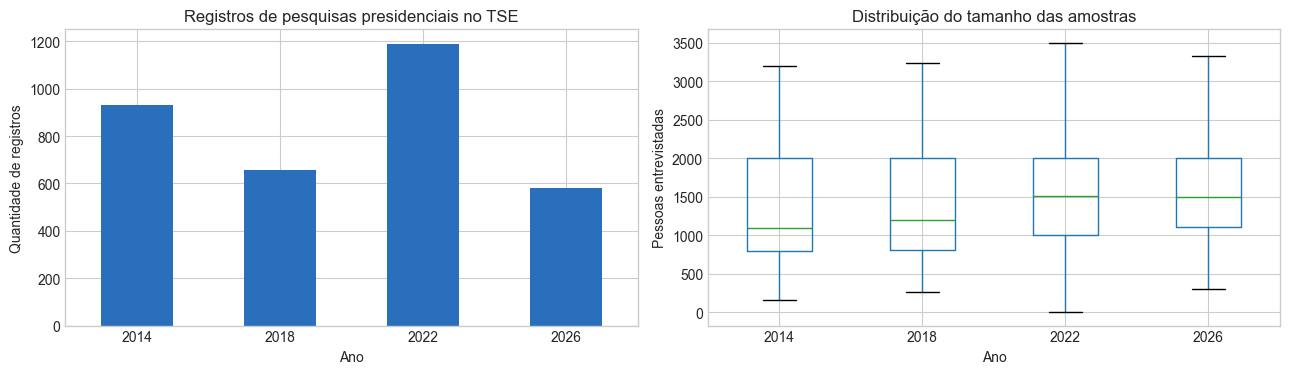

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

resumo_tse_ano["pesquisas_registradas"].plot(
    kind="bar", ax=axes[0], color="#2a6fbb"
)
axes[0].set_title("Registros de pesquisas presidenciais no TSE")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Quantidade de registros")
axes[0].tick_params(axis="x", rotation=0)

tse.boxplot(column="QT_ENTREVISTADO", by="ano_arquivo", ax=axes[1], showfliers=False)
axes[1].set_title("Distribuição do tamanho das amostras")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Pessoas entrevistadas")
plt.suptitle("")
plt.tight_layout()
plt.show()

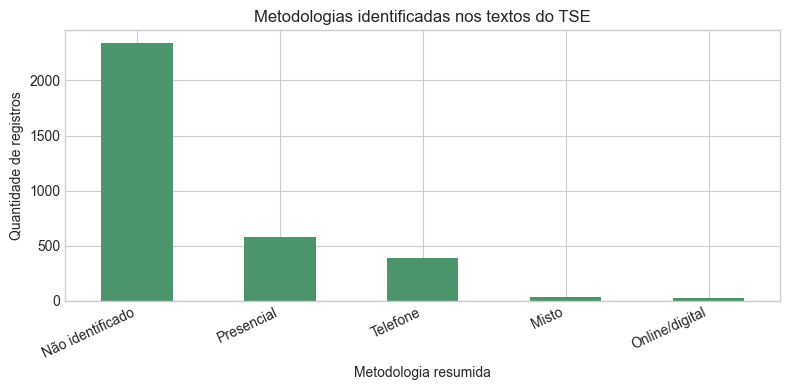

In [15]:
metodologias = tse["metodologia_resumida"].value_counts()
metodologias.plot(kind="bar", figsize=(8, 4), color="#4c956c")
plt.title("Metodologias identificadas nos textos do TSE")
plt.xlabel("Metodologia resumida")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [16]:
foco_brasil = tse[tse["instituto"].isin(["AtlasIntel", "IBOPE", "Ipec"])]
tabela_foco_brasil = pd.crosstab(foco_brasil["instituto"], foco_brasil["ano_arquivo"])
tabela_foco_brasil

ano_arquivo,2014,2018,2022,2026
instituto,,,,
AtlasIntel,0,0,86,24
IBOPE,201,171,0,0
Ipec,2,0,143,3


## 10. Precisão histórica

Agora analisamos a distância entre o percentual pesquisado e o resultado real.

In [17]:
pesquisas_candidatos[["poll_pct", "actual_pct", "signed_error",
                       "absolute_error", "samplesize",
                       "days_to_election"]].describe().round(2)

,poll_pct,actual_pct,signed_error,absolute_error,samplesize,days_to_election
count,1164.00,1164.00,1164.00,1164.00,1164.00,1164.00
mean,44.58,47.81,-3.24,3.95,1173.19,27.34
std,7.00,7.53,3.85,3.12,4346.61,17.41
min,6.80,4.09,-18.16,0.00,102.00,2.00
25%,41.00,45.64,-5.33,1.63,494.00,12.00
50%,45.14,48.00,-2.93,3.17,726.50,26.00
75%,49.00,51.16,-0.86,5.40,1060.00,43.00
max,79.80,90.86,13.07,18.16,84292.00,61.00


In [18]:
descricao_institutos = (
    pesquisas_candidatos.groupby("pollster")["absolute_error"]
    .describe()
    .sort_values("mean")
    .round(2)
)
descricao_institutos

,count,mean,std,min,25%,50%,75%,max
pollster,,,,,,,,
AtlasIntel,20.0,1.37,0.91,0.12,0.75,1.21,1.97,3.37
Marist,98.0,3.02,2.20,0.06,1.37,2.82,3.91,11.18
YouGov,466.0,3.84,3.16,0.03,1.60,3.00,5.07,18.16
Ipsos,580.0,4.28,3.19,0.00,1.81,3.82,6.07,18.06


### MAE, RMSE e tendência do erro

MAE e RMSE medem o tamanho do erro. A tendência mostra se houve superestimação ou subestimação.

In [19]:
mae = pesquisas_candidatos.groupby("pollster")["absolute_error"].mean()
rmse = pesquisas_candidatos.groupby("pollster")["signed_error"].apply(
    lambda erros: np.sqrt(np.mean(erros ** 2))
)
tendencia_erro = pesquisas_candidatos.groupby("pollster")["signed_error"].mean()
quantidade_pesquisas = pesquisas_candidatos.groupby("pollster")["poll_id"].nunique()

metricas_erro = pd.DataFrame({
    "numero_pesquisas": quantidade_pesquisas,
    "MAE": mae,
    "RMSE": rmse,
    "tendencia_erro": tendencia_erro,
}).sort_values("MAE").round(2)

metricas_erro

,numero_pesquisas,MAE,RMSE,tendencia_erro
pollster,,,,
AtlasIntel,10,1.37,1.63,-0.76
Marist,49,3.02,3.73,-2.35
YouGov,233,3.84,4.97,-3.33
Ipsos,290,4.28,5.34,-3.40


O número de pesquisas também deve ser considerado: poucas observações tornam a comparação menos segura.

## 11. Gráficos comparativos

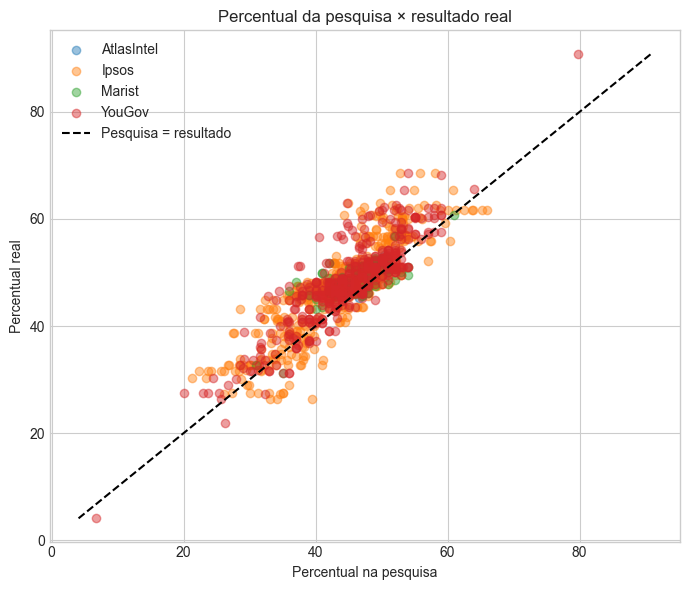

In [20]:
plt.figure(figsize=(7, 6))
for instituto, grupo in pesquisas_candidatos.groupby("pollster"):
    plt.scatter(grupo["poll_pct"], grupo["actual_pct"], alpha=0.45, label=instituto)

limite_min = min(pesquisas_candidatos["poll_pct"].min(), pesquisas_candidatos["actual_pct"].min())
limite_max = max(pesquisas_candidatos["poll_pct"].max(), pesquisas_candidatos["actual_pct"].max())
plt.plot([limite_min, limite_max], [limite_min, limite_max], "k--", label="Pesquisa = resultado")
plt.title("Percentual da pesquisa × resultado real")
plt.xlabel("Percentual na pesquisa")
plt.ylabel("Percentual real")
plt.legend()
plt.tight_layout()
plt.show()

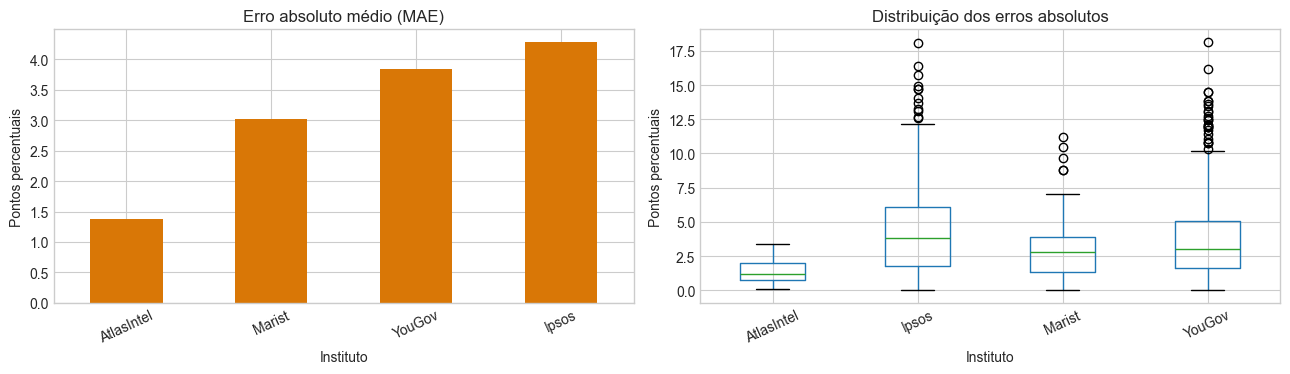

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

metricas_erro["MAE"].sort_values().plot(kind="bar", ax=axes[0], color="#d97706")
axes[0].set_title("Erro absoluto médio (MAE)")
axes[0].set_xlabel("Instituto")
axes[0].set_ylabel("Pontos percentuais")
axes[0].tick_params(axis="x", rotation=25)

pesquisas_candidatos.boxplot(column="absolute_error", by="pollster", ax=axes[1])
axes[1].set_title("Distribuição dos erros absolutos")
axes[1].set_xlabel("Instituto")
axes[1].set_ylabel("Pontos percentuais")
axes[1].tick_params(axis="x", rotation=25)
plt.suptitle("")
plt.tight_layout()
plt.show()

## 12. Erro e distância até a eleição

Agrupamos as pesquisas conforme o número de dias até a votação.

In [22]:
faixas = [-1, 3, 7, 15, 30, np.inf]
rotulos = ["0–3 dias", "4–7 dias", "8–15 dias", "16–30 dias", "30+ dias"]
pesquisas_candidatos["faixa_dias"] = pd.cut(
    pesquisas_candidatos["days_to_election"], bins=faixas, labels=rotulos
)

erro_por_distancia = (
    pesquisas_candidatos.groupby("faixa_dias", observed=False)["absolute_error"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)
erro_por_distancia

,count,mean,median,std
faixa_dias,,,,
0–3 dias,24,2.04,1.80,1.21
4–7 dias,154,2.59,2.53,1.87
8–15 dias,166,3.83,3.27,2.76
16–30 dias,384,4.49,3.82,3.59
30+ dias,436,4.10,3.59,3.04


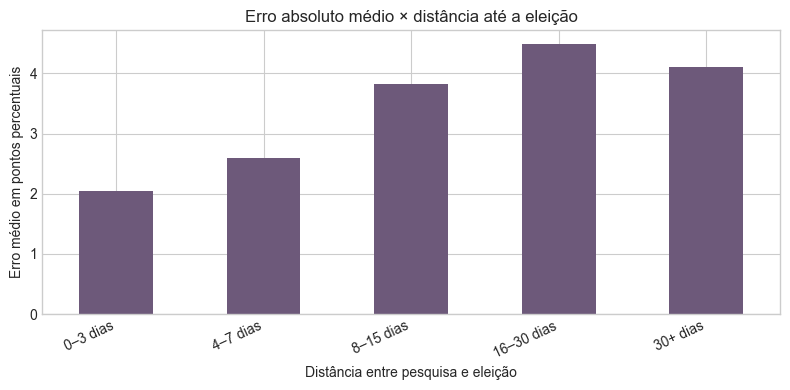

In [23]:
erro_por_distancia["mean"].plot(kind="bar", figsize=(8, 4), color="#6d597a")
plt.title("Erro absoluto médio × distância até a eleição")
plt.xlabel("Distância entre pesquisa e eleição")
plt.ylabel("Erro médio em pontos percentuais")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

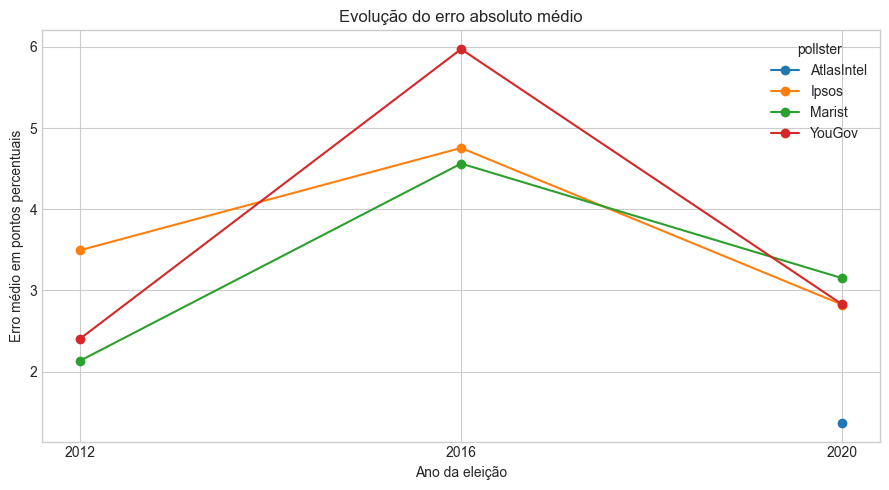

In [24]:
erro_por_ano = (
    pesquisas_candidatos.groupby(["cycle", "pollster"])["absolute_error"]
    .mean().unstack()
)
erro_por_ano.plot(marker="o", figsize=(9, 5))
plt.title("Evolução do erro absoluto médio")
plt.xlabel("Ano da eleição")
plt.ylabel("Erro médio em pontos percentuais")
plt.xticks(anos_escolhidos)
plt.tight_layout()
plt.show()

## 13. Última pesquisa antes da eleição

Selecionamos a pesquisa mais próxima da votação para cada instituto e disputa.

In [25]:
pesquisas_finais = (
    pesquisas.sort_values(["pollster", "race", "days_to_election", "polldate"])
    .drop_duplicates(subset=["pollster", "race"], keep="first")
    .copy()
)

ranking_final = (
    pesquisas_finais.groupby("pollster")
    .agg(
        numero_eleicoes=("race", "nunique"),
        erro_medio_margem=("absolute_margin_error", "mean"),
        tendencia_margem=("margin_error", "mean"),
        desvio_erro_margem=("absolute_margin_error", "std"),
        taxa_acerto_vencedor=("winner_correct", "mean"),
    )
)
ranking_final["taxa_acerto_vencedor"] *= 100
ranking_final = ranking_final.sort_values("erro_medio_margem").round(2)
ranking_final.to_csv(FINAL / "ranking_institutos.csv")
pesquisas_finais.to_csv(FINAL / "polls_final.csv", index=False)
ranking_final

,numero_eleicoes,erro_medio_margem,tendencia_margem,desvio_erro_margem,taxa_acerto_vencedor
pollster,,,,,
AtlasIntel,10,2.04,0.37,1.33,60.00
Marist,28,4.42,2.19,3.18,67.86
Ipsos,60,5.23,2.65,4.04,85.00
YouGov,97,5.33,2.52,4.35,87.63


Acertar o vencedor é importante, mas não substitui a análise do tamanho do erro.

## 14. Metodologia e tamanho da amostra

Comparamos essas variáveis de forma descritiva, sem afirmar relação de causa e efeito.

In [26]:
resumo_metodo = (
    pesquisas_candidatos.assign(
        metodologia=pesquisas_candidatos["methodology"].fillna("Não informada")
    )
    .groupby("metodologia")["absolute_error"]
    .agg(["count", "mean", "median", "std"])
    .query("count >= 20")
    .sort_values("mean")
    .round(2)
)
resumo_metodo

,count,mean,median,std
metodologia,,,,
Probability Panel,108,2.83,2.38,2.08
Live Phone,98,3.02,2.82,2.20
Online Panel,924,4.15,3.38,3.26
Live Phone/Online Panel,32,4.82,4.70,2.91


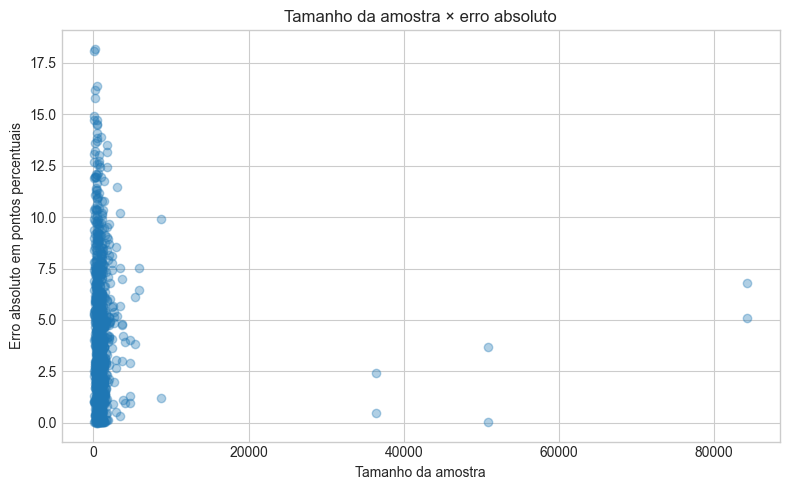

Correlação observada: -0.006


In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(
    pesquisas_candidatos["samplesize"],
    pesquisas_candidatos["absolute_error"],
    alpha=0.35
)
plt.title("Tamanho da amostra × erro absoluto")
plt.xlabel("Tamanho da amostra")
plt.ylabel("Erro absoluto em pontos percentuais")
plt.tight_layout()
plt.show()

correlacao = pesquisas_candidatos[["samplesize", "absolute_error"]].corr().iloc[0, 1]
print(f"Correlação observada: {correlacao:.3f}")

## 15. Pesquisa atual no Brasil — 2026

O gráfico usa o principal cenário estimulado de primeiro turno da [pesquisa AtlasIntel/Bloomberg de julho de 2026](https://cdn.atlasintel.org/498dd172-4381-4192-977c-c4af9787434f.pdf).

Foram entrevistadas 5.021 pessoas entre 22 e 27 de julho. A margem de erro é de 1 ponto percentual e o registro no TSE é BR-08602/2026. É uma fotografia daquela pesquisa, não uma previsão.

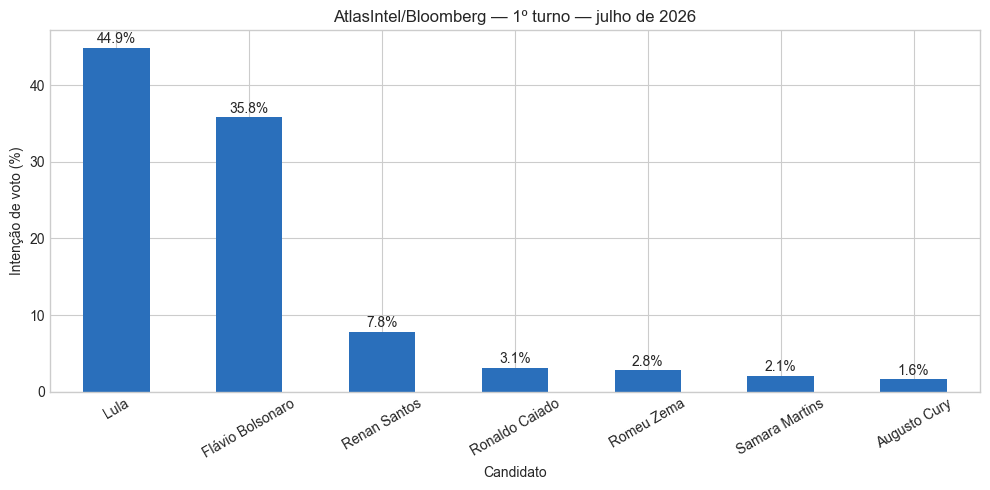

,candidato,percentual
0,Lula,44.9
1,Flávio Bolsonaro,35.8
2,Renan Santos,7.8
3,Ronaldo Caiado,3.1
4,Romeu Zema,2.8
5,Samara Martins,2.1
6,Augusto Cury,1.6


In [28]:
pesquisa_atual = pd.DataFrame({
    "candidato": ["Lula", "Flávio Bolsonaro", "Renan Santos", "Ronaldo Caiado",
                  "Romeu Zema", "Samara Martins", "Augusto Cury"],
    "percentual": [44.9, 35.8, 7.8, 3.1, 2.8, 2.1, 1.6],
})

pesquisa_atual.to_csv(PROCESSED / "pesquisa_atual_atlas_julho_2026.csv", index=False)

ax = pesquisa_atual.plot(
    x="candidato", y="percentual", kind="bar", legend=False,
    figsize=(10, 5), color="#2a6fbb"
)
ax.set_title("AtlasIntel/Bloomberg — 1º turno — julho de 2026")
ax.set_xlabel("Candidato")
ax.set_ylabel("Intenção de voto (%)")
ax.tick_params(axis="x", rotation=30)

for posicao, valor in enumerate(pesquisa_atual["percentual"]):
    ax.text(posicao, valor + 0.6, f"{valor:.1f}%", ha="center")

plt.tight_layout()
plt.show()
pesquisa_atual

## 16. Limitações

- Pesquisas representam o momento da coleta.
- Os institutos possuem quantidades diferentes de observações.
- O arquivo histórico usado não contém a eleição americana de 2024.
- Os registros do TSE não trazem uma tabela pronta com o percentual de cada candidato.
- Correlação não prova causa, manipulação ou influência direta no resultado.

## 17. Conclusão

As bases permitiram limpar dados, calcular medidas descritivas e comparar pesquisas com resultados reais. As métricas devem ser interpretadas em conjunto e sempre respeitando as limitações da amostra.